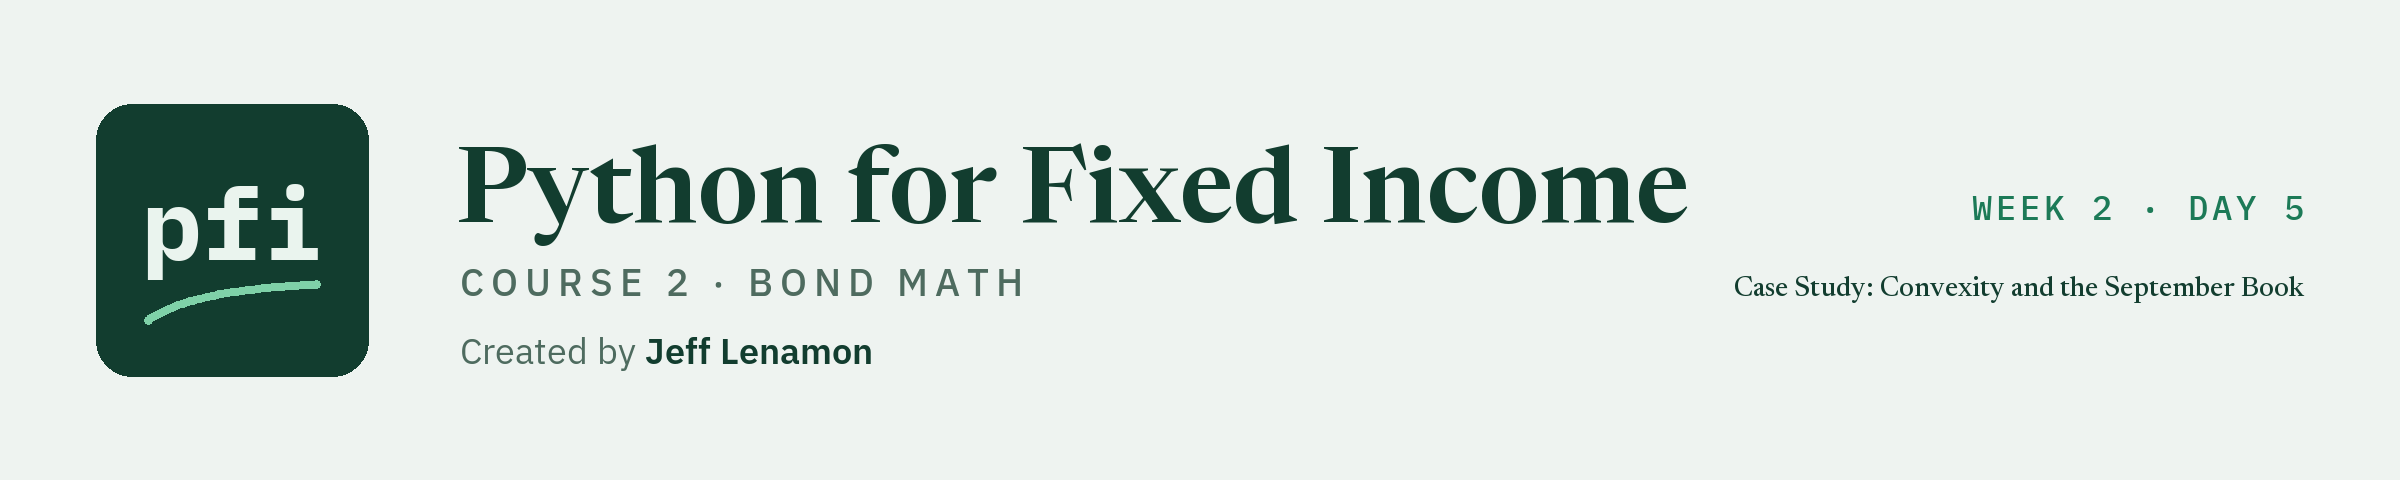

# Case Study: Convexity and the September Book

Week 2, Day 5. Week 2 ends with one new measure and one real job: convexity, the bend that duration's straight line misses, checked with three Excel PRICE cells; then the September book, every bond's price, accrued, yield, and duration reproduced and checked, and the book's DV01 in dollars.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day5/10_case_study_convexity_and_the_september_book.ipynb)

Day 9 gave every bond a duration and a DV01: how far the price moves for a small change in yield. Day 3 drew the price-yield curve and showed that it bends. Today joins the two. Duration is a straight line laid against a curve. For a small move the line and the curve agree; for a large one they part, and the gap has a name: **convexity**.

The day has two halves.

**Hands-on, sections 10.1 to 10.4.** The same four bonds as all week, settled on 30 November 2026 at their issue yields:

1. See where duration's straight line misses the full reprice, and by how much.
2. Add `convexity` to your module, the eighteenth function, and say what its units are.
3. Check it against Excel, which has no convexity function, by a central difference on three `PRICE` cells.
4. Add the convexity term to the duration estimate and compare both with a full reprice.

**Case study, sections 10.5 to 10.10.** The September book, `holdings.csv`: 200 bonds as of 30 September 2026. Every number the week built, run on every bond, and checked against the file with `assert`. Then the book's DV01 in dollars and its duration.

Git closes the week with a `week2` tag and compares it with `week1`.

The issuers are invented, and so is every number. Nothing here says a bond, an issuer, or a sector is good or bad.

The setup cell is the same as all week. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 9.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_10_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_10_x_qo2_t9, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01']


* The two files exactly as day 9 left them: 17 functions and 27 tests. By the end of today there will be 18 functions.

Today's Git step compares the end of week 2 with the end of week 1, by their tags. Your own `my_bondmath` folder has had a `week1` tag since day 5. This work folder is new, so it has no history at all. We rebuild the one commit we need first: week 1 ended just before `add_months`, the first function of week 2, so the start of each file, up to that function, is exactly what week 1 left.

Q. Make the work folder a repository.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_10_x_qo2_t9 and nowhere else


Q. Cut both files back to the end of week 1.

In [7]:
# today's files, as the setup cell wrote them: keep them, to put them back after the week 1 commit
module_today = Path("bondmath.py").read_text(encoding="utf-8")
tests_today = Path("test_bondmath.py").read_text(encoding="utf-8")

# week 1 ended just before add_months and its test, the first of week 2: cut each file there
module_week1 = module_today[:module_today.index("\n\n\ndef add_months")] + "\n"
tests_week1 = tests_today[:tests_today.index("\n\n\ndef test_add_months")] + "\n"
Path("bondmath.py").write_text(module_week1, encoding="utf-8")
Path("test_bondmath.py").write_text(tests_week1, encoding="utf-8")

# count what is left: functions start with "def " at the start of a line, tests with "def test_"
week1_functions = sum(line.startswith("def ") for line in module_week1.splitlines())
week1_tests = sum(line.startswith("def test_") for line in tests_week1.splitlines())
print(f"bondmath.py as week 1 left it: {week1_functions} functions; test_bondmath.py: {week1_tests} tests")

bondmath.py as week 1 left it: 6 functions; test_bondmath.py: 13 tests


* 6 functions and 13 tests: the six functions of week 1, and its tests. `str.index` finds where a piece of text starts, and the slice `[:position]` keeps everything before it.
* `module_today` and `tests_today` still hold today's full text, so nothing is lost.

Q. Commit the week 1 files, and name that commit `week1`.

In [8]:
# commit the week 1 files quietly, then put the name week1 on that commit
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Week 1 as it ended: the files at the week1 tag"
!git -C "{work}" tag week1

Q. Put today's files back, and commit the start of day 10.

In [9]:
# put today's files back exactly as the setup cell wrote them
Path("bondmath.py").write_text(module_today, encoding="utf-8")
Path("test_bondmath.py").write_text(tests_today, encoding="utf-8")
print(f"bondmath.py: {sum(line.startswith('def ') for line in module_today.splitlines())} functions again")

bondmath.py: 17 functions again


In [10]:
# commit the start-of-day files, then show the history with its names
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 10: bondmath.py and test_bondmath.py as day 9 left them"
!git -C "{work}" log --oneline --decorate

885d2c6 (HEAD -> main) Start of day 10: bondmath.py and test_bondmath.py as day 9 left them
2336205 (tag: week1) Week 1 as it ended: the files at the week1 tag


* Two commits. The older one carries the name `tag: week1`; the newer one is the start of day 10, where `HEAD -> main` points. Hashes change on every run.

Q. Type in the four bonds, with their maturities as dates and their issue yields.

In [11]:
from datetime import date

import numpy as np
import matplotlib.pyplot as plt

# the week 2 settlement: Monday 30 November 2026
settlement = date(2026, 11, 30)

bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": [date(2031, 9, 30), date(2033, 9, 30), date(2029, 9, 30), date(2036, 9, 30)],
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
})

bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,yield_pct
0,99001BZA7,Quorvane Energy,QVNE,BBB,5.250,2031-09-30,5.400
1,99002CZA4,Dunmarrow Rail,DNMR,BB+,6.125,2033-09-30,6.125
2,99003DZA1,Pellwick Paper,PLWK,A-,4.750,2029-09-30,4.600
3,99004EZA8,Halvering Foods,HLVF,B+,7.500,2036-09-30,7.700


* The four bonds of the whole week, semiannual, US 30/360, settled between coupons: two months of interest have accrued since 30 September.

## 10.1 Where Duration's Straight Line Misses for a Large Move

Modified duration is the percent change in the dirty price for a 1-point (100 basis point) change in yield, with the sign turned round. As an estimate, for a change in yield dy written as a decimal:

change in dirty price = - modified duration x dy x dirty price

That is a straight line in the yield. Halvering Foods, the longest of the four at ten years, shows the most.

Q. Halvering's dirty price and modified duration on 30 November 2026.

In [12]:
halvering = bonds[bonds["ticker"] == "HLVF"].iloc[0]
# the inputs bondmath takes, in its order: settlement, maturity, coupon, yield
h_inputs = (settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"])

h_dirty = bondmath.dirty_price(*h_inputs)
h_duration = bondmath.modified_duration(*h_inputs)
print(f"Halvering at {halvering['yield_pct']:.2f} percent: dirty price {h_dirty:.6f} per 100, modified duration {h_duration:.6f} years")

Halvering at 7.70 percent: dirty price 99.872491 per 100, modified duration 6.759766 years


* A dirty price of 99.872491 and a modified duration of 6.759766 years. For 100 basis points, duration says the price moves about 6.76 percent, or 6.7511 per 100 of face.
* `*h_inputs` unpacks the tuple into the four arguments, so the same inputs feed every function today.

Q. Move the yield by -300 to +300 basis points. Reprice in full, and compare with duration's straight line.

In [13]:
shifts_bp = [-300, -200, -100, -25, 25, 100, 200, 300]
rows = []
for shift_bp in shifts_bp:
    # the full reprice: the whole bond at the new yield (shift_bp / 100 turns basis points into percent)
    new_dirty = bondmath.dirty_price(settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"] + shift_bp / 100)
    full = new_dirty - h_dirty
    # duration's straight line: dy is the shift as a decimal, 100 bp = 0.01
    dy = shift_bp / 10000
    duration_only = -h_duration * dy * h_dirty
    rows.append({"shift_bp": shift_bp, "full_reprice": full, "duration_only": duration_only, "miss": full - duration_only})

straight_line = pd.DataFrame(rows)
straight_line.round(4)

,shift_bp,full_reprice,duration_only,miss
0,-300,23.2141,20.2534,2.9607
1,-200,14.7737,13.5023,1.2714
2,-100,7.0585,6.7511,0.3073
3,-25,1.7065,1.6878,0.0187
4,25,-1.6694,-1.6878,0.0184
5,100,-6.4633,-6.7511,0.2879
6,200,-12.3867,-13.5023,1.1156
7,300,-17.8202,-20.2534,2.4333


* For 25 basis points either way the line misses by about 0.018 per 100. For 100 it misses by about 0.29, and for 300 by 2.43 (up) and 2.96 (down). Three times the move, about nine times the miss: the miss grows with the square of the shift.
* The miss is positive in every row. When yields fall the price rises **more** than duration says (23.2141 against 20.2534 for -300). When yields rise it falls **less** (-17.8202 against -20.2534 for +300). Duration's line sits below the curve on both sides.

Q. Draw it: Halvering's price-yield curve, and duration's straight line through today's point.

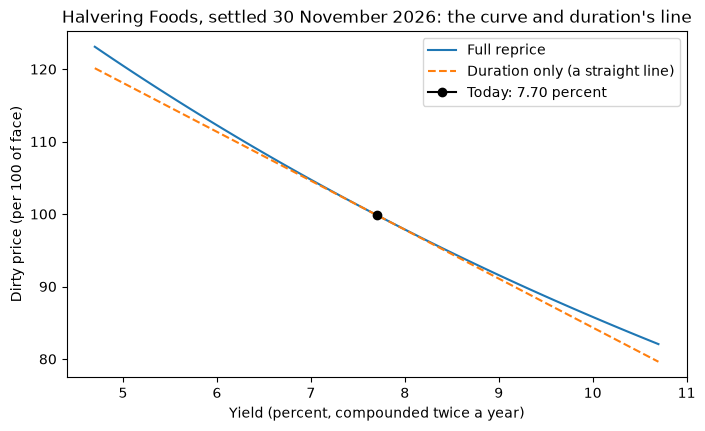

In [14]:
# 61 yields from 300 bp below today's yield to 300 bp above, 10 bp apart
yield_axis = np.linspace(halvering["yield_pct"] - 3, halvering["yield_pct"] + 3, 61)
curve = [bondmath.dirty_price(settlement, halvering["maturity"], halvering["coupon_pct"], y) for y in yield_axis]
# the line: today's dirty price, moved by duration alone (yield in percent, so divide the gap by 100)
line = h_dirty * (1 - h_duration * (yield_axis - halvering["yield_pct"]) / 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(yield_axis, curve, label="Full reprice")
ax.plot(yield_axis, line, linestyle="--", label="Duration only (a straight line)")
ax.plot(halvering["yield_pct"], h_dirty, marker="o", color="black", label="Today: 7.70 percent")
ax.set_title("Halvering Foods, settled 30 November 2026: the curve and duration's line")
ax.set_xlabel("Yield (percent, compounded twice a year)")
ax.set_ylabel("Dirty price (per 100 of face)")
ax.legend()
plt.show()

* The dashed line touches the curve at today's yield and nowhere else. Near the dot they are hard to tell apart; out at the edges the curve is above the line at both ends. The gap between them is what duration leaves out.

## 10.2 Convexity and `convexity`

Duration is the slope of the price-yield curve, divided by the price. **Convexity** is how fast that slope changes: the curvature, also divided by the price. With both, the estimate of the change in price gains a second term:

change in dirty price / dirty price = - modified duration x dy + 0.5 x convexity x dy squared

The second term is a square, so it is positive whether yields rise or fall. That is exactly the sign of the miss in section 10.1.

For a bullet bond, convexity is a weighted sum over the cash flows, like Macaulay duration. Each cash flow CF at time t years (the same t = (w + k) / f as day 9) contributes

CF x t x (t + 1/f) / (1 + y/f) to the power (f x t + 2)

and the sum is divided by the dirty price. Duration weights each cash flow by its time; convexity weights it by roughly its time squared. So a cash flow twice as far away adds about four times as much: **long bonds have far more convexity.** The unit is years squared.

Q. Add `convexity` to the end of `bondmath.py`. Read the docstring before you run the cell.

In [15]:
%%writefile -a bondmath.py


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring says the units first: percent in, years squared out, and **unscaled**. It writes the formula, the price change estimate it feeds, and how Excel checks it, since Excel has no function for it.
* The loop has the shape of day 9's `macaulay_duration`. Where duration added each cash flow's time times its present value, convexity adds `cash_flow * time_years * (time_years + 1 / frequency)`, discounted by two more powers of `(1 + period_yield)`. The present values are summed again in `total_pv`, which is the dirty price.

Q. Reload the module, and compute the convexity of all four bonds next to their modified durations.

In [16]:
importlib.reload(bondmath)

rows = []
for bond in bonds.itertuples():
    inputs = (settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    rows.append({"issuer": bond.issuer, "maturity": bond.maturity,
                 "modified_duration": bondmath.modified_duration(*inputs), "convexity": bondmath.convexity(*inputs)})

risk = pd.DataFrame(rows)
risk.round(4)

,issuer,maturity,modified_duration,convexity
0,Quorvane Energy,2031-09-30,4.1804,20.8885
1,Dunmarrow Rail,2033-09-30,5.4623,36.3887
2,Pellwick Paper,2029-09-30,2.6051,8.3305
3,Halvering Foods,2036-09-30,6.7598,59.5474


* Pellwick, under three years left: modified duration 2.6051, convexity 8.3305. Halvering, nearly ten years: 6.7598 and 59.5474. Duration is 2.6 times larger; convexity is 7.1 times larger. Convexity grows roughly with the square of the time to the cash flows.
* Every value is positive. A bullet bond's price-yield curve always bends this way.

**Other sources scale convexity differently.** Some divide the number by 100, and some report half of it, so that their estimate reads "+ convexity x dy squared" with no 0.5 in front. **The course's number is unscaled**, in years squared, and goes into the estimate as 0.5 x convexity x dy squared with dy as a decimal. Halvering's 59.5474 would read 0.5955 divided by 100, or 29.7737 halved. Before you compare a convexity number from anywhere else, find out which scaling it uses.

Q. What does the convexity term add for Halvering, for 100 and for 300 basis points?

In [17]:
h_convexity = bondmath.convexity(*h_inputs)
for shift_bp in [100, 300]:
    dy = shift_bp / 10000
    # 0.5 x convexity x dy squared is a share of the dirty price; times 100 for percent
    print(f"{shift_bp} bp: convexity adds {0.5 * h_convexity * dy ** 2 * 100:.4f} percent of the price, "
          f"{0.5 * h_convexity * dy ** 2 * h_dirty:.4f} per 100 of face")

100 bp: convexity adds 0.2977 percent of the price, 0.2974 per 100 of face
300 bp: convexity adds 2.6796 percent of the price, 2.6762 per 100 of face


* For 100 basis points the term adds 0.2977 percent, against duration's 6.76: small. For 300 basis points it adds 2.6796 percent, nine times as much. That is the term duration left out.

## 10.3 Checking It When Excel Has No Convexity Function

Excel has `DURATION` and `MDURATION`, but no convexity function. The check is built from the definition instead: convexity is the curvature of price in yield, divided by price. Price the bond at three yields, today's, one basis point lower, and one higher. Then the curvature is

(price at y + h + price at y - h - 2 x price at y) / h squared

with h = 0.0001 (1 basis point as a decimal). Divide by the dirty price. This is a **central difference**. Only clean prices are needed on top, because accrued interest does not change with the yield and cancels out.

Q. The central difference for Halvering in Python, against `convexity`.

In [18]:
h = 0.0001  # 1 basis point, as a decimal
# bondmath takes percent, so the yields move by h x 100 = 0.01 percent
p_mid = bondmath.price(settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"])
p_down = bondmath.price(settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"] - h * 100)
p_up = bondmath.price(settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"] + h * 100)

central_difference = (p_up + p_down - 2 * p_mid) / (h_dirty * h ** 2)
print(f"central difference: {central_difference:.6f} years squared")
print(f"convexity:          {h_convexity:.6f} years squared")
print(f"gap:                {abs(central_difference - h_convexity):.1e}")

central difference: 59.547369 years squared
convexity:          59.547364 years squared
gap:                4.8e-06


* The two agree to 5e-06. They are not identical: a central difference over 1 basis point measures the average curvature across that step, not the curvature at a point. That is why the course's tolerance for this check is 1e-3, well above the gap.

Q. Excel's reference file holds the same central difference, computed by Excel from three `PRICE` cells, in the `convexity_fd` column. Compare all four bonds.

In [19]:
reference = pd.read_csv("bondmath_excel_reference.csv")
# the week 2 rows: the week 1 bonds settled on 30 November 2026, case_id the CUSIP
week2 = reference[reference["group"] == "week2"].set_index("case_id")

risk["excel_convexity_fd"] = [week2.loc[cusip, "convexity_fd"] for cusip in bonds["cusip"]]
risk["gap"] = (risk["convexity"] - risk["excel_convexity_fd"]).abs()
assert risk["gap"].max() < 1e-3, "a convexity differs from Excel's central difference"
risk[["issuer", "convexity", "excel_convexity_fd", "gap"]]

,issuer,convexity,excel_convexity_fd,gap
0,Quorvane Energy,20.888538,20.888538,4.492871e-07
1,Dunmarrow Rail,36.388736,36.388738,1.494057e-06
2,Pellwick Paper,8.330536,8.330536,1.299189e-08
3,Halvering Foods,59.547364,59.547369,4.827389e-06


* All four within the tolerance, the largest gap 4.8e-06, for Halvering. The gap grows with the bond's length, because the curvature changes faster across the 1 basis point step on a long bond.

**Excel side by side: convexity from three `PRICE` cells.** Tested in Excel, for Halvering. In a blank sheet type:

* A1: `=PRICE(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100,100,2,0)`, today's clean price. It returns 98.622491.
* A2: the same with `7.7/100-0.0001` as the yield, 1 basis point lower. It returns 98.690032.
* A3: the same with `7.7/100+0.0001`, 1 basis point higher. It returns 98.555009.
* A4: the accrued, `=100*7.5/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2036,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2036,9,30),2,0)`. It returns 1.250000.
* A5: `=(A2+A3-2*A1)/((A1+A4)*0.0001^2)`. It returns 59.54736851639378, exactly the `convexity_fd` value in the reference file.

The yields are written as decimals with the bump subtracted or added inside the formula, so the `/100` stays in view. `A1+A4` is the dirty price.

Q. Add the test. Read it before you run the cell.

In [20]:
%%writefile -a test_bondmath.py


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]

Appending to test_bondmath.py


* One loop over every row of the reference file, against Excel's central difference, with the tolerance of 1e-3.
* It skips the rows in the final coupon period (`coupnum` of 1). Day 8 showed that Excel prices the last period with simple interest, so Excel's curvature there is not the same measure as the formula's.
* The 200 holdings rows are in the reference file too, so this test ties `convexity` to the data file the case study uses.

Q. Run the tests.

In [21]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

............................                                             [100%]
28 passed in 1.04s



* `28 passed`: the 27 from days 1 to 9, and today's one.

## 10.4 Duration Plus Convexity Against a Full Reprice

Back to section 10.1's table, now with the convexity term added to the estimate.

Q. For each shift: the full reprice, duration only, and duration plus convexity.

In [22]:
rows = []
for shift_bp in shifts_bp:
    new_dirty = bondmath.dirty_price(settlement, halvering["maturity"], halvering["coupon_pct"], halvering["yield_pct"] + shift_bp / 100)
    dy = shift_bp / 10000
    rows.append({
        "shift_bp": shift_bp,
        "full_reprice": new_dirty - h_dirty,
        "duration_only": -h_duration * dy * h_dirty,
        # the second term: half the convexity times dy squared, as a share of the dirty price
        "duration_and_convexity": (-h_duration * dy + 0.5 * h_convexity * dy ** 2) * h_dirty,
    })

estimates = pd.DataFrame(rows)
estimates["miss_duration"] = estimates["full_reprice"] - estimates["duration_only"]
estimates["miss_both"] = estimates["full_reprice"] - estimates["duration_and_convexity"]
estimates.round(4)

,shift_bp,full_reprice,duration_only,duration_and_convexity,miss_duration,miss_both
0,-300,23.2141,20.2534,22.9297,2.9607,0.2845
1,-200,14.7737,13.5023,14.6917,1.2714,0.0820
2,-100,7.0585,6.7511,7.0485,0.3073,0.0100
3,-25,1.7065,1.6878,1.7064,0.0187,0.0002
4,25,-1.6694,-1.6878,-1.6692,0.0184,-0.0002
5,100,-6.4633,-6.7511,-6.4538,0.2879,-0.0095
6,200,-12.3867,-13.5023,-12.3129,1.1156,-0.0738
7,300,-17.8202,-20.2534,-17.5772,2.4333,-0.2430


* For 100 basis points the miss falls from 0.2879 to -0.0095 per 100 (up) and from 0.3073 to 0.0100 (down). For 300 basis points, from 2.4333 to -0.2430 and from 2.9607 to 0.2845.
* Adding convexity leaves a small miss that changes sign: the estimate is now slightly too high when yields rise and slightly too low when they fall. Two terms describe a curve well, not perfectly. The full reprice is the answer; the estimate is a quick way to see what drives it.

Q. Draw the curve, the straight line, and the duration-and-convexity estimate together.

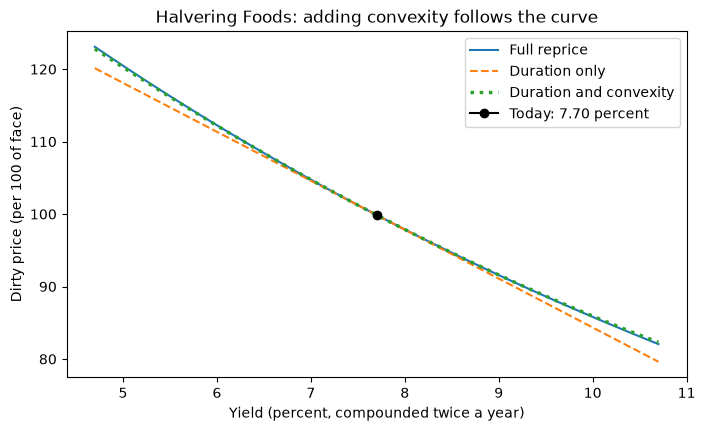

In [23]:
# the estimate is a parabola in the yield: dy as a decimal at every point of the axis
dy_axis = (yield_axis - halvering["yield_pct"]) / 100
parabola = h_dirty * (1 - h_duration * dy_axis + 0.5 * h_convexity * dy_axis ** 2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(yield_axis, curve, label="Full reprice")
ax.plot(yield_axis, line, linestyle="--", label="Duration only")
ax.plot(yield_axis, parabola, linestyle=":", linewidth=2.5, label="Duration and convexity")
ax.plot(halvering["yield_pct"], h_dirty, marker="o", color="black", label="Today: 7.70 percent")
ax.set_title("Halvering Foods: adding convexity follows the curve")
ax.set_xlabel("Yield (percent, compounded twice a year)")
ax.set_ylabel("Dirty price (per 100 of face)")
ax.legend()
plt.show()

* The dotted parabola lies almost on the curve across the whole 600 basis points. The straight line peels away at both ends.

Q. All four bonds, for a 100 basis point rise: the estimate and the full reprice, in percent of the dirty price.

In [24]:
rows = []
for bond in bonds.itertuples():
    inputs = (settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    dirty, duration, convexity = bondmath.dirty_price(*inputs), bondmath.modified_duration(*inputs), bondmath.convexity(*inputs)
    dy = 0.01  # +100 bp as a decimal
    up = bondmath.dirty_price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct + 1)
    rows.append({"issuer": bond.issuer,
                 "estimate_pct": (-duration * dy + 0.5 * convexity * dy ** 2) * 100,
                 "full_reprice_pct": (up - dirty) / dirty * 100})

up_100 = pd.DataFrame(rows)
up_100["miss_pct"] = up_100["full_reprice_pct"] - up_100["estimate_pct"]
up_100.round(6)

,issuer,estimate_pct,full_reprice_pct,miss_pct
0,Quorvane Energy,-4.075935,-4.077845,-0.001910
1,Dunmarrow Rail,-5.280391,-5.284763,-0.004372
2,Pellwick Paper,-2.563475,-2.563985,-0.000510
3,Halvering Foods,-6.462029,-6.471508,-0.009478


* For a 100 basis point rise the estimate is within 0.0095 percent of the full reprice for every bond. Halvering falls 6.4715 percent in full against an estimate of 6.4620.

**Excel side by side: the estimate and the full reprice.** Tested in Excel, in the same sheet as section 10.3, for Halvering. In A6 type `=(-MDURATION(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100,2,0)*0.01+0.5*A5*0.01^2)*100`: duration and the convexity in A5, for dy = 0.01. It returns -6.462029. In A8 type `=(PRICE(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100+0.01,100,2,0)-A1)/(A1+A4)*100`: the full reprice at a yield 100 basis points higher, as a percent of the dirty price. It returns -6.471508. With `+0.01` turned to `-0.01` and the duration term's sign turned to plus, the fall gives 7.057503 and 7.067493. The estimate in A6 uses Excel's central difference rather than the exact convexity, a difference of about 5e-06 in convexity, which changes nothing at six decimals. All four bonds were checked the same way.

## Case Study: The September Book

### Context

`holdings.csv` is the course's book: 200 invented corporate bonds as of 30 September 2026, the same file Course 1 explored. Every bond is a fixed-rate bullet that pays semiannually on the 30/360 day count, and every bond settles on the as-of date. The file was produced by a program, the course's data generator, and each bond's `price`, `accrued`, `yield_pct`, and `duration` (modified duration, in years) are rounded to 3 decimals.

Two weeks ago the module could price a bond only on a coupon date. Now it holds everything needed to rebuild those four columns for any bond on any settlement date.

### Objective

You are the desk's analyst, and the file is someone else's work. Before using it, check it, bond by bond, with your own module:

1. `price` from `yield_pct`, the clean price per 100.
2. `accrued`, from the dates and the coupon.
3. `yield_pct` from `price`, the other way round.
4. `duration`, modified duration in years. And add convexity, which the file does not hold.
5. Run the same checks on the wider file the holdings were drawn from, and describe what does not match.
6. Add up the book: its DV01 in dollars and its market-value weighted duration.

Each check is an `assert` at the course's tolerances, so the notebook stops if a single bond disagrees.

### The data

| Column | Meaning | Used for |
| --- | --- | --- |
| `as_of_date` | 2026-09-30 for every bond; settlement is the same day | settlement |
| `cusip`, `issuer`, `sector`, `rating` | invented identifiers | naming a bond |
| `coupon` | annual coupon, percent of face | input |
| `maturity` | maturity date | input |
| `yield_pct` | yield, percent, semiannual | input, and checked |
| `price`, `accrued`, `duration` | clean price and accrued per 100, modified duration in years, 3 decimals | checked |
| `par_held`, `market_value` | face held and market value, dollars | the book's totals |

### The tolerances

A column rounded to 3 decimals can be off by up to 0.0005 from the exact number, so the check for `price`, `accrued`, and `duration` is 0.0005, plus 1e-9 for the last digits of floating point. A yield solved from a rounded price inherits the price's rounding, so its check is 0.001 percent. These are the course's tolerances for reproducing a data file.

### How we will solve it

One section for each item of the objective, each built from functions you wrote this week, applied one bond at a time with `zip` and a list comprehension, as on day 5. Two Predict questions along the way. The book is described, never judged: nothing here says any bond should be bought or sold.

## 10.5 The Book, Read and Checked

Q. Read the file, turn its dates into `date` values, and check its shape.

In [25]:
book = pd.read_csv(data_folder + "holdings.csv")

# bondmath takes datetime.date values: pandas dates first, then .dt.date, as on day 6
book["settlement"] = pd.to_datetime(book["as_of_date"]).dt.date
book["maturity_date"] = pd.to_datetime(book["maturity"]).dt.date

# checks that stop: 200 different bonds, one as-of date, every bond maturing after it
assert len(book) == 200 and book["cusip"].is_unique, "expected 200 different bonds"
assert book["as_of_date"].nunique() == 1, "expected one as-of date"
assert (book["maturity_date"] > book["settlement"]).all(), "a bond matures on or before the as-of date"

print(f"{len(book)} bonds as of {book['settlement'].iloc[0]}, maturing {book['maturity_date'].min()} to {book['maturity_date'].max()}")
book[["cusip", "issuer", "rating", "coupon", "maturity", "yield_pct", "price", "accrued", "duration"]].head()

200 bonds as of 2026-09-30, maturing 2027-10-02 to 2056-08-23


,cusip,issuer,rating,coupon,maturity,yield_pct,price,accrued,duration
0,99080CAE8,Bezane Finance,BBB-,7.000,2032-06-18,5.606,106.727,1.983,4.627
1,99049XAE2,Bezamyth Machinery,B,8.125,2029-04-17,9.220,97.556,3.679,2.165
2,99039NAC0,Bezoquil Freight,BB,5.125,2030-06-03,5.509,98.730,1.666,3.250
3,99039NAG1,Bezoquil Freight,BB,6.125,2053-04-09,6.756,92.261,2.909,12.113
4,99034IAD4,Bezorin Finance,BBB-,4.625,2036-04-05,5.600,92.883,2.248,7.338


* All three checks passed in silence. The bonds have from about 1 to about 30 years left.

Q. Write the tolerances down once, with their reasons, before using them.

In [26]:
# a column the file rounds to 3 decimals: half of 0.001, plus room for the last digits of floating point
ROUNDED_3 = 0.0005 + 1e-9
# a yield solved from the file's rounded price, in percent
YIELD_FROM_ROUNDED_PRICE = 0.001
print(f"price, accrued, duration: {ROUNDED_3}; yield from price: {YIELD_FROM_ROUNDED_PRICE} percent")

price, accrued, duration: 0.000500001; yield from price: 0.001 percent


## 10.6 Price and Accrued from the File's Yields

Q. Recompute every bond's clean price from its yield, and its accrued interest from its dates, and check both against the file.

In [27]:
# one bond at a time: zip hands each function one row's settlement, maturity, coupon, and yield together
book["price_calc"] = [bondmath.price(s, m, c, y)
                      for s, m, c, y in zip(book["settlement"], book["maturity_date"], book["coupon"], book["yield_pct"])]
book["accrued_calc"] = [bondmath.accrued_interest(s, m, c)
                        for s, m, c in zip(book["settlement"], book["maturity_date"], book["coupon"])]

price_gap = (book["price_calc"] - book["price"]).abs()
accrued_gap = (book["accrued_calc"] - book["accrued"]).abs()
assert price_gap.max() <= ROUNDED_3, "a price differs from the file by more than its rounding"
assert accrued_gap.max() <= ROUNDED_3, "an accrued differs from the file by more than its rounding"

print(f"price:   largest gap {price_gap.max():.7f}, bond {book.loc[price_gap.idxmax(), 'cusip']}")
print(f"accrued: largest gap {float(accrued_gap.max())!r}, bond {book.loc[accrued_gap.idxmax(), 'cusip']}")

price:   largest gap 0.0004985, bond 99123TAH3
accrued: largest gap 0.0005000000000000004, bond 99113JAA2


* Both checks passed for all 200 bonds. The largest price gap is 0.0004985, inside the rounding of a 3-decimal number.
* The largest accrued gap prints as 0.0005000000000000004: a hair **above** 0.0005. That is why the tolerance has the extra 1e-9.

Q. Look at that bond.

In [28]:
widest = accrued_gap.idxmax()
print(f"{book.loc[widest, 'cusip']}: coupon {book.loc[widest, 'coupon']} percent, maturity {book.loc[widest, 'maturity']}")
print(f"accrued from the module: {float(book.loc[widest, 'accrued_calc'])!r}")
print(f"accrued in the file:     {book.loc[widest, 'accrued']}")

99113JAA2: coupon 5.25 percent, maturity 2036-03-24
accrued from the module: 0.0875
accrued in the file:     0.087


* The module's accrued is 0.0875: the exact answer ends in a 5 at the fourth decimal, a tie, and the file rounded it to 0.087. The true gap is exactly 0.0005. Floating point stores neither number exactly, so the difference comes out at 0.0005000000000000004. A tolerance of exactly 0.0005 would have failed a bond that is right.

## 10.7 Yield from the File's Price

Now the other way round: solve each bond's yield from the file's price with day 8's `yield_to_maturity`, and compare with the file's `yield_pct`. The file's price is rounded to 3 decimals, so the yield solved from it is a little off. The question is where it is most off.

**Predict 1**

Every price in the file carries a rounding error of up to 0.0005 per 100. Solved back into a yield, which bonds will miss the file's yield by the most?

> A) The longest bonds, because they have the most cash flows.
>
> B) No pattern: rounding errors are random.
>
> C) The shortest bonds, because a small price error is a large yield error when duration is small.

Decide, then run the cell.

In [29]:
book["yield_calc"] = [bondmath.yield_to_maturity(s, m, c, p)
                      for s, m, c, p in zip(book["settlement"], book["maturity_date"], book["coupon"], book["price"])]
book["duration_calc"] = [bondmath.modified_duration(s, m, c, y)
                         for s, m, c, y in zip(book["settlement"], book["maturity_date"], book["coupon"], book["yield_pct"])]

yield_gap = (book["yield_calc"] - book["yield_pct"]).abs()
assert yield_gap.max() <= YIELD_FROM_ROUNDED_PRICE, "a yield differs from the file by more than the price's rounding allows"

# the five largest yield gaps, with each bond's duration beside it
book["yield_gap"] = yield_gap
book.nlargest(5, "yield_gap")[["cusip", "maturity", "duration_calc", "price", "yield_pct", "yield_calc", "yield_gap"]]

,cusip,maturity,duration_calc,price,yield_pct,yield_calc,yield_gap
177,99006GAC4,2027-10-02,0.927120,101.347,5.851,5.850560,0.000440
112,99026AAD1,2027-10-24,1.004956,100.230,4.898,4.897567,0.000433
125,99003DAG5,2027-10-28,1.016945,100.459,4.680,4.679576,0.000424
188,99111HAA8,2028-01-03,1.192764,101.036,4.513,4.512654,0.000346
71,99088KAA0,2028-02-27,1.310381,98.352,7.751,7.750682,0.000318


* The answer is C. The five largest gaps all belong to bonds with modified durations of 1.31 years or less. The largest, 0.000440 percent, is a bond with 0.93 years of duration.
* The reason is duration read backwards. A yield change of dy moves the price by about duration x dy x price. So a price error moves the yield by about price error / (duration x price). The same 0.0005 of price is several times more yield on a one-year bond than on a ten-year bond.
* Every gap is inside 0.001 percent (0.1 basis points), so the check passed.

Q. On average, how far are the short and the long bonds from the file's yield?

In [30]:
short = book["duration_calc"] < 3
long = book["duration_calc"] > 7
print(f"modified duration under 3 years: {short.sum()} bonds, average gap {yield_gap[short].mean():.6f} percent")
print(f"modified duration over 7 years:  {long.sum()} bonds, average gap {yield_gap[long].mean():.6f} percent")

modified duration under 3 years: 36 bonds, average gap 0.000139 percent
modified duration over 7 years:  79 bonds, average gap 0.000027 percent


* 36 short bonds, average gap 0.000139 percent; 79 long bonds, 0.000027 percent. The same pattern on average.

## 10.8 Duration, and Convexity as a New Column

Section 10.7 already computed every bond's modified duration, from the file's yield, to sort the yield gaps.

Q. Check it against the file's `duration`, then add a convexity column.

In [31]:
duration_gap = (book["duration_calc"] - book["duration"]).abs()
assert duration_gap.max() <= ROUNDED_3, "a duration differs from the file by more than its rounding"
print(f"duration: largest gap {duration_gap.max():.7f}, bond {book.loc[duration_gap.idxmax(), 'cusip']}")

# a column the file does not hold
book["convexity"] = [bondmath.convexity(s, m, c, y)
                     for s, m, c, y in zip(book["settlement"], book["maturity_date"], book["coupon"], book["yield_pct"])]
book[["duration_calc", "convexity"]].describe().round(4)

duration: largest gap 0.0004982, bond 99010KAH8


,duration_calc,convexity
count,200.0000,200.0000
mean,6.4704,72.5274
std,3.3505,76.3239
min,0.9271,1.3480
25%,3.8800,17.9547
50%,6.3062,50.0327
75%,8.1401,81.9089
max,16.0425,369.3686


* Duration passes for all 200 bonds, the largest gap 0.0004982. That completes the four columns: price, accrued, yield, and duration, reproduced for every bond at the course's tolerances.
* Modified duration runs from 0.9271 to 16.0425 years. Convexity runs from 1.3480 to 369.3686 years squared: the longest duration is 17 times the shortest, and the largest convexity 274 times the smallest.

Q. The reference file holds Excel's central difference for every holdings bond. Do all 200 convexities agree with it?

In [32]:
# the holdings rows of the reference file: the same 200 bonds, as of the same date, case_id the CUSIP
excel_fd = reference[reference["group"] == "holdings"].set_index("case_id")["convexity_fd"]
convexity_gap = (book.set_index("cusip")["convexity"] - excel_fd).abs()
assert len(convexity_gap) == 200 and convexity_gap.max() < 1e-3, "a convexity differs from Excel's central difference"
print(f"convexity against Excel's central difference: largest gap {convexity_gap.max():.1e}, on {convexity_gap.idxmax()}")

convexity against Excel's central difference: largest gap 2.2e-04, on 99053BAB9


* All 200 agree within 1e-3, the largest gap 2.2e-04. The new column has the same answer key as the test.

## 10.9 Two Systems Disagree, Again: the Benchmark

`benchmark.csv` is the wider file the holdings were drawn from: 821 bonds in the same columns, 200 of them held. Running the same four checks on it would mean copying four cells. Better to put the checks in one function, once, and run it on any file of this shape. **Rerun, do not redo.**

Q. Write `column_gaps`, a function that returns each bond's four gaps to the file.

In [33]:
def column_gaps(bonds):
    """The gap between the module and the file for price, accrued, yield_pct, and duration, one row per bond.

    bonds: a DataFrame with the columns of holdings.csv (dates as text). Returns absolute gaps in the file's
    units (per 100, percent, years), indexed by cusip.
    """
    rows = []
    for row in bonds.itertuples():
        s, m = date.fromisoformat(row.as_of_date), date.fromisoformat(row.maturity)
        rows.append({
            "cusip": row.cusip,
            "price": abs(bondmath.price(s, m, row.coupon, row.yield_pct) - row.price),
            "accrued": abs(bondmath.accrued_interest(s, m, row.coupon) - row.accrued),
            "yield_pct": abs(bondmath.yield_to_maturity(s, m, row.coupon, row.price) - row.yield_pct),
            "duration": abs(bondmath.modified_duration(s, m, row.coupon, row.yield_pct) - row.duration),
        })
    return pd.DataFrame(rows).set_index("cusip")


# the tolerance for each column, in the same order
tolerance = pd.Series({"price": ROUNDED_3, "accrued": ROUNDED_3, "yield_pct": YIELD_FROM_ROUNDED_PRICE, "duration": ROUNDED_3})

# first on the holdings, where every bond passed: the function must agree with sections 10.6 to 10.8
holdings_gaps = column_gaps(pd.read_csv(data_folder + "holdings.csv"))
assert (holdings_gaps <= tolerance).all().all()
print(f"holdings: {len(holdings_gaps)} bonds, every gap inside its tolerance")

holdings: 200 bonds, every gap inside its tolerance


* `holdings_gaps <= tolerance` compares each column with its own tolerance, because pandas lines the Series up with the columns by name. `.all().all()` asks: every bond, in every column?

Q. Now the benchmark. Which bonds fall outside a tolerance?

In [34]:
benchmark = pd.read_csv(data_folder + "benchmark.csv")
benchmark_gaps = column_gaps(benchmark)

# a bond is outside if any one of its four gaps is above its tolerance
outside = benchmark_gaps[(benchmark_gaps > tolerance).any(axis=1)]
print(f"benchmark: {len(benchmark_gaps)} bonds, {len(outside)} outside a tolerance")
outside.round(6)

benchmark: 821 bonds, 2 outside a tolerance


,price,accrued,yield_pct,duration
cusip,,,,
99018SAA8,0.000162,0.028917,0.000019,0.005182
99128YAE4,0.004826,0.052333,0.000762,0.005623


* Exactly two: `99018SAA8` and `99128YAE4`. These are the two bonds of day 6's box, "Two systems disagree", the only bonds in the file that mature on 28 February of a year that is not a leap year. 28 February is the last day of the month in those years, so Excel's month-end rule, which the module follows, puts their coupons on 31 August and 28 February. The data generator kept the day of the month, the 28th, so its coupons fall on 28 August and 28 February.
* Different coupon dates mean a different count of days accrued, so `accrued` differs for both, and so does `duration`, whose cash flow times start from the next coupon. For `99128YAE4` the clean price differs too; for `99018SAA8` the price happens to land inside the tolerance.

Q. Leave the two out by name, and check that every other bond passes.

In [35]:
# named, not filtered by a rule: these two are known, and any new failure must still stop the notebook
month_end_pair = ["99018SAA8", "99128YAE4"]
assert sorted(outside.index) == sorted(month_end_pair), "a bond other than the known pair is outside a tolerance"

others = benchmark_gaps.drop(month_end_pair)
assert (others <= tolerance).all().all()
print(f"the other {len(others)} benchmark bonds: every gap inside its tolerance")
benchmark[benchmark["cusip"].isin(month_end_pair)][["cusip", "maturity", "coupon", "price", "accrued", "duration"]]

the other 819 benchmark bonds: every gap inside its tolerance


,cusip,maturity,coupon,price,accrued,duration
96,99018SAA8,2038-02-28,5.125,99.492,0.456,8.512
706,99128YAE4,2035-02-28,9.500,108.318,0.844,5.801


* 819 bonds pass every check. The two are left out **by name**, with a reason written next to them, so that a third bond that fails for a new reason would still stop the notebook.
* Neither system is wrong. Both are conventions, and for a real bond the bond's own documents decide which dates it pays on. What matters on a desk is knowing that two systems can disagree on one bond, and checking which convention each number was built on before comparing them.

## 10.10 Book DV01 in Dollars, and the Book's Duration

The file is checked. Now add it up. Two totals describe a book's sensitivity to rates:

* **Book DV01 in dollars**: how many dollars the book's value changes for a 1 basis point move in every yield. Each position's DV01 in dollars is its DV01 per 100 times par held / 100 (day 9), and the book's is their sum.
* **Market-value weighted duration**: each bond's modified duration, weighted by its share of the book's market value. Market value uses the dirty price: par held x (price + accrued) / 100.

Q. Market value for every position, against the file's `market_value`.

In [36]:
# market value in dollars: par held times the dirty price per 100
book["market_value_calc"] = book["par_held"] * (book["price"] + book["accrued"]) / 100
total_market_value = book["market_value_calc"].sum()

# the control total: the file's own market value column, to the cent
assert abs(total_market_value - book["market_value"].sum()) < 0.005, "market value does not tie to the file"
print(f"face held:    {book['par_held'].sum():,.0f} dollars")
print(f"market value: {total_market_value:,.2f} dollars, equal to the file's total to the cent")

face held:    489,000,000 dollars
market value: 490,819,215.00 dollars, equal to the file's total to the cent


* 489,000,000 dollars of face and 490,819,215.00 dollars of market value, equal to the file's column to the cent.

Q. Book DV01 in dollars, and the market-value weighted duration.

In [37]:
# each position: DV01 per 100 of face, times par held / 100, in dollars per basis point
book["dv01_dollars"] = [bondmath.dv01(s, m, c, y) * par / 100
                        for s, m, c, y, par in zip(book["settlement"], book["maturity_date"], book["coupon"],
                                                   book["yield_pct"], book["par_held"])]
book_dv01_dollars = book["dv01_dollars"].sum()

# each bond's share of the book's market value, then the weighted average of the durations
weights = book["market_value_calc"] / total_market_value
book_duration = (weights * book["duration_calc"]).sum()

print(f"book DV01: {book_dv01_dollars:,.2f} dollars per basis point")
print(f"market-value weighted modified duration: {book_duration:.4f} years")

book DV01: 306,996.11 dollars per basis point
market-value weighted modified duration: 6.2548 years


* The book changes value by about 306,996 dollars for each basis point that every yield moves, falling when yields rise. Its market-value weighted duration is 6.2548 years.

**Predict 2**

Multiply the book's duration by its market value and by 0.0001, one basis point as a decimal. How does the result compare with the book DV01?

> A) About 6 times larger, because duration is in years.
>
> B) The same, up to the rounding of the file's prices.
>
> C) Much smaller, because the weights add up to 1.

Decide, then run the cell.

In [38]:
duration_view = book_duration * total_market_value * 0.0001
print(f"duration x market value x 0.0001: {duration_view:,.2f} dollars")
print(f"book DV01:                        {book_dv01_dollars:,.2f} dollars")
print(f"difference:                       {book_dv01_dollars - duration_view:,.2f} dollars")

duration x market value x 0.0001: 306,996.21 dollars
book DV01:                        306,996.11 dollars
difference:                       -0.10 dollars


* The answer is B. They differ by 0.10 dollars out of 306,996.
* Each position's DV01 in dollars is its modified duration x its market value x 0.0001. Add them up and the market values factor out as weights: book DV01 = book duration x book market value x 0.0001. The two totals are one number, said in two units: years, and dollars per basis point. The 10 cents between them come from the file's prices, rounded to 3 decimals, in the market values; the DV01 column uses the module's unrounded dirty prices.
* So for this book, each million dollars of market value carries about 625.48 dollars of DV01.

**Observations**

* Every one of the 200 bonds reproduces: price, accrued, and duration within 0.0005 of the file's 3-decimal values, and yield from price within 0.001 percent. The largest gaps are rounding, including a rounding tie in `accrued`.
* Yields solved from rounded prices miss most on the shortest bonds, because a small price error is a large yield error when duration is small.
* In the benchmark, every bond reproduces except the two that mature on 28 February of a non-leap year, where the data generator and Excel's month-end rule put the coupons on different days.
* Convexity across the book runs from 1.35 to 369.37 years squared, and agrees with Excel's central difference for all 200 bonds.
* The book holds 489,000,000 dollars of face worth 490,819,215.00 dollars, with a DV01 of 306,996.11 dollars per basis point and a market-value weighted duration of 6.2548 years.

These describe the file and the book. None of them says which bond anyone should buy or sell.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Price, 1 bp lower | `bondmath.price(..., 7.7 - 0.01)` | A2: `=PRICE(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100-0.0001,100,2,0)` | 98.690032 |
| Convexity, central difference | `bondmath.convexity(...)` | A5: `=(A2+A3-2*A1)/((A1+A4)*0.0001^2)` | 59.547369 |
| Estimate for +100 bp, percent | `(-duration * 0.01 + 0.5 * convexity * 0.01 ** 2) * 100` | A6: `=(-MDURATION(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100,2,0)*0.01+0.5*A5*0.01^2)*100` | -6.462029 |
| Full reprice for +100 bp, percent | `bondmath.dirty_price(..., 7.7 + 1)` | A8: `=(PRICE(DATE(2026,11,30),DATE(2036,9,30),7.5/100,7.7/100+0.01,100,2,0)-A1)/(A1+A4)*100` | -6.471508 |
| Book DV01, dollars | `book["dv01_dollars"].sum()` | `=SUMPRODUCT(E2:E201,H2:H201)/100` | 306,996.11 |
| Book market value, dollars | `book["market_value_calc"].sum()` | `=SUM(I2:I201)` | 490,819,215.00 |
| Weighted duration, years | `(weights * book["duration_calc"]).sum()` | `=SUMPRODUCT(I2:I201,J2:J201)/SUM(I2:I201)` | 6.254772 |

The book sheet, tested in Excel with all 200 bonds: settlement in column A, maturity in B, coupon in C, yield in D, par held in E, the file's price in F and accrued in G, one bond to a row from row 2. Column H holds each bond's DV01 per 100, in H2 `=MDURATION(A2,B2,C2/100,D2/100,2,0)*(PRICE(A2,B2,C2/100,D2/100,100,2,0)+100*C2/100/2*COUPDAYBS(A2,B2,2,0)/COUPDAYS(A2,B2,2,0))/10000`, filled down. Column I is market value, `=E2*(F2+G2)/100`, and column J is `=MDURATION(A2,B2,C2/100,D2/100,2,0)`. `SUMPRODUCT` multiplies two columns row by row and adds the products, which is the dollar DV01 of every position summed in one cell. Excel's three totals equal the module's: the book DV01 to 6e-11 dollars, the market value and the weighted duration exactly.

Q. Does `convexity` agree with Excel's central difference on the holdings and week 2 rows of the reference file?

In [39]:
rows = []
basis_name = {0: "30/360", 1: "ACT/ACT"}
for row in reference[reference["group"].isin(["holdings", "week2"])].itertuples():
    settlement_date, maturity_date = date.fromisoformat(row.settlement), date.fromisoformat(row.maturity)
    result = bondmath.convexity(settlement_date, maturity_date, row.coupon_pct, row.yield_pct, int(row.frequency), basis_name[row.basis])
    rows.append({"case_id": row.case_id, "group": row.group, "python": result, "excel_fd": row.convexity_fd})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel_fd"]).abs()
assert answer_key["gap"].max() < 1e-3, "a row differs from Excel's central difference"
answer_key.groupby("group")["gap"].agg(["count", "max"])

,count,max
group,,
holdings,200,0.000224
week2,8,0.000005


* 200 holdings rows and 8 week 2 rows, every gap far inside 1e-3. The test from section 10.3 runs the same comparison on every row of the file outside the final coupon period.

To try it: build the five cells of section 10.3 in a blank sheet for Halvering, then change the 7.7 in A1, A2, and A3 to another yield and watch A5 move. Convexity, like duration, depends on the yield.

## Save the Day with Git

First, commit today's work. Then today's Git step closes the week: **a `week2` tag**, and a comparison of the two tags.

Q. What has changed since the start of the day?

In [40]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 30 ++++++++++++++++++++++++++++++
 test_bondmath.py |  9 +++++++++
 2 files changed, 39 insertions(+)


* ` M` beside both files: 30 lines added to `bondmath.py` and 9 to `test_bondmath.py`.
* The `??` lines are untracked: the two reference files and `__pycache__/`. This work folder has no `.gitignore`; yours does, since day 6.

Q. Commit today's work.

In [41]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add convexity, checked against a central difference on Excel PRICE" -m "Duration alone misses the bend in the price-yield curve; week 2 ends with the book reproduced."

Q. Name the commit that ends week 2, and show the history with its names.

In [42]:
# tag names the last commit; tag alone lists the tags; --decorate shows the names
!git -C "{work}" tag week2
!git -C "{work}" tag
!git -C "{work}" log --oneline --decorate

week1
week2


c784f31 (HEAD -> main, tag: week2) Add convexity, checked against a central difference on Excel PRICE
885d2c6 Start of day 10: bondmath.py and test_bondmath.py as day 9 left them
2336205 (tag: week1) Week 1 as it ended: the files at the week1 tag


* Two tags now. `week1` stays on the commit where week 1 ended, and `week2` is on today's commit, with `HEAD -> main`.

Q. What did week 2 add to the module and the tests? Compare the two tags.

In [43]:
# diff between two names: every change from the week1 commit to the week2 commit
!git -C "{work}" diff --stat week1 week2

 bondmath.py      | 304 +++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 155 ++++++++++++++++++++++++++++
 2 files changed, 459 insertions(+)


* `git diff --stat week1 week2` compares the two commits the tags name, whatever has happened since. 304 lines added to `bondmath.py` and 155 to `test_bondmath.py`, and nothing removed: week 2 only added code. The lines are the 12 functions and 15 tests that days 6 to 10 added, with the helpers and blank lines around them.
* A tag can stand anywhere a commit can: `git diff week1 week2 -- bondmath.py` would show the lines themselves, and `git log --oneline week1..week2` the commits between them. Day 12 compares against `week2` again.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the `%%writefile -a bondmath.py` cell in section 10.2, without its first line. In `test_bondmath.py`, do the same with the `%%writefile -a test_bondmath.py` cell in section 10.3. Save both files. Your folder needs no week 1 rebuild: it has had its `week1` tag since day 5.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
............................                                             [100%]
28 passed in 0.08s
```

If you added the exercise functions of days 1 to 9 with their tests, you will see more. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add convexity, checked against a central difference on Excel PRICE" -m "Duration alone misses the bend in the price-yield curve; week 2 ends with the book reproduced."
```

**Step 5.** Tag the end of week 2, and compare it with week 1.

```powershell
git tag week2
git log --oneline --decorate
git diff --stat week1 week2
```

Your `git log` shows every commit of the two weeks, with `tag: week1` on day 5's commit and `tag: week2` on today's. Your `diff --stat` counts will be larger than the notebook's if you kept your exercise functions, and it lists `.gitignore` too, which you added on day 6.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Say where duration's straight line misses the full reprice, why the miss has the same sign for rises and falls, and why it grows with the square of the move.
* Compute convexity with `convexity`, say its units, and say how other sources scale it differently.
* Check convexity with a central difference on three `PRICE` cells, because Excel has no convexity function.
* Estimate a price change with duration and convexity, and compare it with a full reprice.
* Reproduce a book's price, accrued, yield, and duration columns for every bond with `assert` checks at stated tolerances, and explain each tolerance.
* Name the bonds two systems disagree on, and leave them out by name.
* Add up a book's DV01 in dollars and its market-value weighted duration, and say why the two are one number.
* Name the end of a week with `git tag`, and compare two tags with `git diff --stat`.

That closes week 2. Every number in the September book is now yours to rebuild. Week 3 starts on day 11 with the Treasury curve, so that each bond's yield can be split into a curve and a spread.

## Exercises

The exercises use the second set of four bonds from week 1, settled on the same day as the lesson's bonds, 30 November 2026, at their issue yields. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [44]:
from datetime import date

settlement = date(2026, 11, 30)

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": [date(2030, 9, 30), date(2028, 9, 30), date(2032, 9, 30), date(2034, 9, 30)],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8.60


### Exercise 1

Q. Compute the convexity of each exercise bond on 30 November 2026 with `bondmath.convexity`. Store Calderby's convexity in **ex1_calderby**, and the ticker of the bond with the largest convexity, as a string, in **ex1_largest**.

In [45]:
ex1_calderby = ...
ex1_largest = ...

In [46]:
check("Exercise 1 Calderby convexity", ex1_calderby, 40.151840380885986)
check("Exercise 1 largest convexity", ex1_largest, 'CLDB')

Exercise 1 Calderby convexity: not attempted yet
Exercise 1 largest convexity: not attempted yet


### Exercise 2

Q. Yields on Osmere Chemicals rise by 200 basis points. Estimate the percent change in its dirty price with duration and convexity, (-modified duration x dy + 0.5 x convexity x dy squared) x 100 with dy = 0.02, and store it in **ex2_estimate_pct**. Then reprice Osmere in full at the higher yield and store the percent change in its dirty price in **ex2_full_pct**.

In [47]:
ex2_estimate_pct = ...
ex2_full_pct = ...

In [48]:
check("Exercise 2 estimate", ex2_estimate_pct, -9.316371448913852)
check("Exercise 2 full reprice", ex2_full_pct, -9.340810588211228)

Exercise 2 estimate: not attempted yet
Exercise 2 full reprice: not attempted yet


### Exercise 3

Q. Add a function to your module. `convexity_adjustment(convexity, shift_bp)` returns the percent change in price that comes from convexity alone, 0.5 x convexity x dy squared x 100, where dy is `shift_bp` as a decimal. Write the docstring first: units, convention, and the scaling of convexity it expects. Then add a test to `test_bondmath.py`, called `test_convexity_adjustment_hand_cases`, with cases you can check by hand: a convexity of 100 and 100 basis points gives 0.5 percent, the same for -100 basis points, and no shift gives 0. Run pytest, and store `bondmath.convexity_adjustment` for Calderby's convexity and 100 basis points in **ex3_calderby**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [49]:
%%writefile -a bondmath.py


# Exercise 3: write convexity_adjustment(convexity, shift_bp) below this line

Appending to bondmath.py


In [50]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_convexity_adjustment_hand_cases() below this line

Appending to test_bondmath.py


In [51]:
# run pytest, reload the module, then call your function
ex3_calderby = ...

In [52]:
check("Exercise 3 Calderby adjustment", ex3_calderby, 0.20075920190442995)

Exercise 3 Calderby adjustment: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `convexity` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Convexity in years squared, unscaled (not divided by 100 or by 2).

Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
Excel has no convexity function; the check is a central difference on three PRICE cells.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [53]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_convexity(settlement, maturity, coupon_pct, yield_pct, frequency=2, basis="30/360"):
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = bondmath.coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        # time to each cash flow, counted in coupon periods
        periods = w + k
        total_pv += cash_flow / (1 + period_yield) ** periods
        curvature += cash_flow * periods * (periods + 1) / (1 + period_yield) ** (periods + 2)
    return curvature / total_pv

Q. Before you run the next cell: what should the function return for Halvering on 30 November 2026? Section 10.2 has the number.

In [54]:
print(f"Halvering's convexity from the assistant's function: {assistant_convexity(settlement, date(2036, 9, 30), 7.5, 7.7):.4f}")

Halvering's convexity from the assistant's function: 238.1895


Q. Test the function against every row of Excel's reference file before you trust it.

In [55]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")
basis_name = {0: "30/360", 1: "ACT/ACT"}

for row in reference.itertuples():
    if row.coupnum == 1:
        continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
    settlement_date, maturity_date = date.fromisoformat(row.settlement), date.fromisoformat(row.maturity)
    result = assistant_convexity(settlement_date, maturity_date, row.coupon_pct, row.yield_pct, int(row.frequency), basis_name[row.basis])
    # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
    assert abs(result - row.convexity_fd) < 1e-3, f"{row.case_id}: {result:.4f} against Excel's {row.convexity_fd:.4f}"

print("Every row outside the final period matches Excel's central difference")

AssertionError: 99080CAE8: 105.4320 against Excel's 26.3580

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the assistant's convexity for Halvering, `assistant_convexity(settlement, date(2036, 9, 30), 7.5, 7.7)`, in **ex4_halvering**.

In [56]:
# fix the function above and run the test again, then store the answer
ex4_halvering = ...

In [57]:
check("Exercise 4 Halvering convexity", ex4_halvering, 59.54736368900526)

Exercise 4 Halvering convexity: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```